### NLTK

NLTK чаще всего используют как «конструктор» для пайплайна предобработки текста: токенизация → стоп-слова → стемминг/лемматизация → POS-теги → (опционально) NER, chunking и простая классификация.
#### Основные модули и задачи
nltk.tokenize, nltk.corpus, nltk.stem, nltk.tag, nltk.chunk, nltk.classify, nltk.metrics, nltk.probability и nltk.corpus.wordnet

**Токенизация (nltk.tokenize):**

Задача: разбить текст на предложения и слова.​
Чаще всего используются: sent_tokenize, word_tokenize, иногда RegexpTokenizer и TweetTokenizer для специфических форматов.

Типичные задачи: базовая предобработка перед любыми моделями, построение n-грамм, POS-теггинг, TF-IDF и т.д.

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download("punkt")

text = "Hello world. Good morning!"
sentences = sent_tokenize(text)
words = word_tokenize(text.lower())

print(sentences) 
words

['Hello world.', 'Good morning!']


['hello', 'world', '.', 'good', 'morning', '!']

**Стоп-слова и корпуса (nltk.corpus):**

nltk.corpus даёт доступ к >50 корпусам (Brown, Reuters и др.), словарям (WordNet) и спискам стоп-слов. Самое частое — stopwords.words("english") для фильтрации «шумовых» слов, плюс иногда корпусные данные для экспериментов.

Задачи: очистка текста перед векторизацией/классификацией, быстрые эксперименты на стандартных корпусах.

In [ ]:
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

words = ["this", "is", "a", "simple", "example"]
filtered = [w for w in words if w not in stop_words]
filtered

['simple', 'example']

**Стемминг и лемматизация (nltk.stem, nltk.stem.wordnet):**

Стемминг — грубое обрезание окончаний (быстро, но иногда «криво»), лемматизация — поиск нормальной формы по словарю (WordNet).

Чаще всего: PorterStemmer и WordNetLemmatizer

Задачи: получение базовой формы для уменьшения размерности словаря и улучшения качества признаков (классификация, тематическое моделирование).

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download("wordnet")

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

word = "running"
print(stemmer.stem(word))                
print(lemmatizer.lemmatize(word, "v"))

run
run


**POS‑теггинг (nltk.tag.pos_tag):**

POS-теггинг помечает части речи (NOUN, VERB, ADJ и т.п.) и используется для фильтрации/анализа структуры.

Самая частая функция — nltk.pos_tag, в связке с word_tokenize.

Задачи: выделение существительных/прилагательных для ключевых слов, упрощённый синтаксический анализ, подготовка к chunking/NER.

In [ ]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.download("averaged_perceptron_tagger_eng")

text = "The quick brown fox jumps over the lazy dog."
tokens = word_tokenize(text)
tags = pos_tag(tokens)
print(tags)

[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]


**Chunking и NER (nltk.chunk, nltk.ne_chunk):**

Chunking выделяет фразы (NP, VP) на основе POS-тегов, NER находит именованные сущности (PERSON, ORG, GPE).

Чаще всего используется nltk.ne_chunk для простого rule-based NER.

Задачи: извлечение имён людей, компаний, локаций для информационного извлечения, простых аналитических отчётов и т.п.

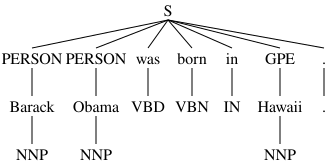

In [ ]:
import nltk
from nltk import pos_tag, ne_chunk
from nltk.tokenize import word_tokenize

nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

text = "Barack Obama was born in Hawaii."
tokens = word_tokenize(text)
tags = pos_tag(tokens)
tree = ne_chunk(tags)
tree

**WordNet и семантика (nltk.corpus.wordnet):**

WordNet — лексическая база: синонимы, гиперонимы/гипонимы, определения, примеры.​
Частые функции: synsets, lemmas, definition, examples.

Задачи: семантический поиск, расширение запросов, генерация признаков (кол-во значений, расстояния между синсетами).

In [ ]:
from nltk.corpus import wordnet as wn
nltk.download("wordnet")

syns = wn.synsets("bank")
for s in syns[:3]:
    print(s.name(), "→", s.definition())

bank.n.01 → sloping land (especially the slope beside a body of water)
depository_financial_institution.n.01 → a financial institution that accepts deposits and channels the money into lending activities
bank.n.03 → a long ridge or pile


**Классификация (nltk.classify) и метрики:**

NLTK содержит простые обёртки для моделей на базе признаков (Naive Bayes и др.) и метрики качества (nltk.metrics).

Используются для учебных задач: sentiment analysis, спам/хэм, классификация кратких текстов.

Задачи: быстрый baseline без внешних библиотек (sklearn), демонстрация полного текста → признаки → модель.

In [ ]:
import nltk
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import movie_reviews

nltk.download("movie_reviews")

# Простейшее представление: слова → True
def doc_features(words):
    return {w: True for w in words}

documents = [
    (doc_features(movie_reviews.words(fileid)), category)
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]

train_set, test_set = documents[:1500], documents[1500:]
clf = NaiveBayesClassifier.train(train_set)
nltk.classify.accuracy(clf, test_set)

0.942

### Gensim

Gensim — это библиотека для векторных представлений текста и тематического моделирования: TF‑IDF, LSI/LSA, LDA, Word2Vec/Doc2Vec/FastText и работа с большими корпусами.​
Её обычно используют поверх NLTK/spaCy: те чистят и токенизируют текст, а Gensim строит словарь, корпус, эмбеддинги и темы.

##### Основные модули и типичные задачи

Ключевые части Gensim:
- gensim.corpora — словари и корпуса (Dictionary, MmCorpus и др.).​
- gensim.models — модели: Word2Vec, Doc2Vec, FastText, TfidfModel, LsiModel, LdaModel, HdpModel.​
- gensim.similarities — индексы похожести документов (Similarity, MatrixSimilarity, SparseMatrixSimilarity).​

Основные практические сценарии:
- Построение признаков документов (TF‑IDF, LSI) для классификации/кластеризации.​
- Тематическое моделирование (LDA/LSI) для обзора больших коллекций текстов.​
- Обучение эмбеддингов слов/документов (Word2Vec/Doc2Vec/FastText).​
- Поиск похожих документов/фраз.

**Dictionary и корпус (gensim.corpora.Dictionary):**

Dictionary — это мэппинг «слово → id», корпус — список документов в формате Bag‑of‑Words (список (id, count)).

С ними работают почти все модели Gensim, поэтому они — первый шаг после токенизации.

Частые методы:
- Dictionary(texts) — построить словарь по токенизированным документам.​
- doc2bow(tokens) — перевести список токенов документа в BoW.​
- filter_extremes() — отфильтровать слишком редкие/частые слова.

In [14]:
from gensim.corpora import Dictionary

texts = [
    ["human", "interface", "computer"],
    ["survey", "user", "computer", "system"],
    ["human", "system", "response"]
]

dictionary = Dictionary(texts)              
bow_corpus = [dictionary.doc2bow(t) for t in texts]

print(dictionary.token2id)                  
print(bow_corpus[0])                        

{'computer': 0, 'human': 1, 'interface': 2, 'survey': 3, 'system': 4, 'user': 5, 'response': 6}
[(0, 1), (1, 1), (2, 1)]


**TF‑IDF (gensim.models.TfidfModel):**

TfidfModel превращает BoW‑корпус в TF‑IDF‑представление.​
Используется как лёгкий способ получить числовые признаки документов без sklearn.

Типичные задачи:
- Признаки для классификации (логистическая регрессия, SVM и т.п.).​
- Вход для LSI/LSA и других моделей измерения семантической близости.

In [15]:
from gensim.models import TfidfModel

tfidf = TfidfModel(bow_corpus)               
tfidf_corpus = tfidf[bow_corpus]     

for doc in tfidf_corpus:
    print(doc)

[(0, np.float64(0.32718457421365993)), (1, np.float64(0.32718457421365993)), (2, np.float64(0.8865102981879297))]
[(0, np.float64(0.2448297500958463)), (3, np.float64(0.6633689723434505)), (4, np.float64(0.2448297500958463)), (5, np.float64(0.6633689723434505))]
[(1, np.float64(0.32718457421365993)), (4, np.float64(0.32718457421365993)), (6, np.float64(0.8865102981879297))]


**LSI/LSA (gensim.models.LsiModel):**

LSI (Latent Semantic Indexing/Analysis) — по сути SVD над TF‑IDF‑матрицей, даёт плотные вещественные вектора тем.​

Модель LsiModel сжимает пространство признаков и улучшает семантическую близость документов.

Задачи: семантический поиск, поиск похожих документов, снижение размерности.

In [16]:
from gensim.models import LsiModel

lsi = LsiModel(tfidf_corpus, id2word=dictionary, num_topics=2)
lsi_doc = lsi[tfidf_corpus[0]]       # представление документа в теме-спейсе

print(lsi.print_topics())            # просмотр тем

[(0, '0.488*"response" + 0.488*"interface" + 0.360*"human" + 0.327*"user" + 0.327*"survey" + 0.301*"system" + 0.301*"computer"'), (1, '0.582*"survey" + 0.582*"user" + -0.348*"interface" + -0.348*"response" + -0.257*"human" + 0.086*"system" + 0.086*"computer"')]


**LDA (gensim.models.LdaModel):**

LDA (Latent Dirichlet Allocation) — вероятностное тематическое моделирование: каждый документ — смесь тем, каждая тема — распределение по словам.​
LdaModel — одна из самых популярных моделей Gensim.

Частые методы/аргументы:
- num_topics — число тем.​
- passes, iterations — качество/скорость обучения.​
- get_document_topics(bow) — темы конкретного документа.

Задачи: обзор больших коллекций (отзывы, новости, тикеты), тегирование документов темами, аналитика.

In [17]:
from gensim.models import LdaModel

lda = LdaModel(bow_corpus, num_topics=5, id2word=dictionary, passes=10)
topics = lda.print_topics(num_words=5)
for t in topics:
    print(t)

(0, '0.273*"system" + 0.273*"human" + 0.273*"response" + 0.045*"computer" + 0.045*"interface"')
(1, '0.143*"human" + 0.143*"computer" + 0.143*"system" + 0.143*"response" + 0.143*"interface"')
(2, '0.143*"human" + 0.143*"computer" + 0.143*"system" + 0.143*"interface" + 0.143*"response"')
(3, '0.273*"computer" + 0.273*"human" + 0.273*"interface" + 0.045*"system" + 0.045*"response"')
(4, '0.222*"user" + 0.222*"survey" + 0.222*"system" + 0.222*"computer" + 0.037*"human"')


**Word2Vec (gensim.models.Word2Vec):**

Word2Vec в Gensim — классическая реализация CBOW/Skip‑gram с потоковой подачей данных.​

Он учит эмбеддинги слов на корпусе и даёт API для поиска похожих слов, аналогий и симметрий.

Часто используемые атрибуты/методы:
- Параметры: vector_size, window, min_count, sg (0=CBOW, 1=Skip‑gram).​
- model.wv — объект KeyedVectors с эмбеддингами.​
- wv.most_similar, wv.similarity, wv.most_similar_cosmul.​

Задачи:
- Признаки для классификации/кластеризации текстов (усреднение эмбеддингов по документу).​
- Семантический поиск и рекомендации по словам/фразам.

In [19]:
from gensim.models import Word2Vec

sentences = [["this", "is", "a", "sentence"], ["this", "is", "another", "sentence"]]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

vec = w2v.wv["sentence"]                    # вектор слова
similar = w2v.wv.most_similar("sentence")   # топ-похожие слова

print(vec)
similar

[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.5080082e-03  2.46979

[('is', -0.01083916611969471),
 ('a', -0.02775035798549652),
 ('this', -0.05234673246741295),
 ('another', -0.111670583486557)]

**Doc2Vec и FastText:**

Doc2Vec — расширение Word2Vec, даёт эмбеддинги для целых документов/параграфов.​
FastText (модуль FastText) строит эмбеддинги с учётом субслов (n‑грамм), что даёт лучшую устойчивость к редким и OOV‑словам.​

Задачи: классификация документов, рекомендация похожих документов, кластеризация.

Пример Doc2Vec (упрощённо):

In [21]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

docs = [
    TaggedDocument(words=["cat", "say", "meow"], tags=[0]),
    TaggedDocument(words=["dog", "say", "woof"], tags=[1]),
]

d2v = Doc2Vec(docs, vector_size=50, window=3, min_count=1, workers=4)
doc_vec = d2v.infer_vector(["new", "cat", "text"])

doc_vec


array([-0.00483057, -0.00574476,  0.00664456,  0.00239728, -0.00013459,
       -0.00827881,  0.00911088, -0.00926082, -0.0076767 ,  0.00179352,
       -0.0077223 ,  0.00865081, -0.00022518,  0.00487832,  0.00661274,
        0.00493943, -0.0033163 ,  0.00837281, -0.00319951,  0.0074372 ,
       -0.00283619,  0.00060665,  0.00996125, -0.00407011,  0.00476766,
        0.00740595,  0.00062166, -0.00202483,  0.00924402,  0.00963739,
        0.00363991, -0.00879172, -0.00297469,  0.00610161,  0.00247987,
        0.00470236,  0.00131694,  0.00430912, -0.00452051,  0.00730173,
        0.00084631, -0.00323928,  0.00113166, -0.00822581,  0.00179174,
       -0.00881696, -0.00731476, -0.00766185,  0.0077283 , -0.00205141],
      dtype=float32)

**Similarities (gensim.similarities):**

gensim.similarities строит индекс похожести для быстрых запросов «найди топ‑N похожих документов».​

Используется поверх BoW/TF‑IDF/LSI/LDA‑представлений.

Задачи: поиск похожих документов (поиск по базе, рекомендации, дедупликация).

In [22]:
from gensim.similarities import MatrixSimilarity

index = MatrixSimilarity(tfidf_corpus)               # индекс по TF-IDF
query_bow = dictionary.doc2bow(["human", "computer"])
query_tfidf = tfidf[query_bow]

sims = index[query_tfidf]                            # массив схожестей
list(enumerate(sims))                                # (doc_id, similarity)

[(0, np.float32(0.46270886)),
 (1, np.float32(0.17312075)),
 (2, np.float32(0.23135443))]